# 27 · E1n: the linear family and the compact nonlinear model, fitted cleanly

**Where Notebook 26 left off.** The 2 × 2 was meant to separate the two things L1 adds to L0: a nonlinearity, and synapse-resolved weights. It was only half informative.
* **Informative:** `L1c` (sigmoid neurons, L0's three class weights, 345 parameters) was genuinely fitted, and it predicts held-out responses **0.096 worse than L0** [−0.153, −0.049]. A nonlinearity does not help even when over-fitting of many weights is ruled out.
* **Not informative:** L0, L1 and `L0w` (linear, a weight per synapse, 982 parameters) never left their starts; the best validation step was 0 on every fold. Their starts had been fitted on all training pairs, *including the inner validation pairs*, so validation could only get worse. This was the caveat registered in Notebook 26. As a result:
  * the linear resolution test (`L0w` vs L0) was not carried out;
  * "L0 converged" was vacuous.

**Two questions remain open:**
1. Does a linear network need **synapse-specific weights**, or do contact counts and signs set them (`L0w` vs L0)? This decides how strong E1's C2 statement can be.
2. **How good does L0 get** under a principled stopping rule?

**This notebook removes the leak.** Every model is fitted **from scratch on the inner-training pairs only** (80 % of each outer fold's training pairs, the same split as Notebook 26), with early stopping on inner validation pairs that no fit has seen.
* **L0:** E1's initialization.
* **`L0w`:** from that clean L0, with zero deviations (stage-wise, still clean).
* **`L1c`:** two random starts, keeping the one with the better validation loss (selection on validation pairs only).

L1 itself is not refitted; Notebooks 25–26 settled it. No package change.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, pickle, time, datetime, numpy as np, matplotlib.pyplot as plt, jax, jax.numpy as jnp
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 22, 0), \
    f"Notebook 27 needs closurebench >= 0.22.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M_
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
N_BOOT, THRESHOLD, VAL_FRAC = 2000, 0.05, 0.2
TAG = "" if MODE == "full" else f"_{MODE}"
E1_TAG = "_laptop" if MODE == "smoke" else TAG
MODELS = ("L0", "L1c", "L0w")
ES = {"smoke": dict(MAX_LIN=30, MAX_NL=30, EVAL_EVERY=10, PAT_LIN=2, PAT_NL=2, RESTARTS_NL=2),
      "laptop": dict(MAX_LIN=6000, MAX_NL=3000, EVAL_EVERY=100, PAT_LIN=5, PAT_NL=3, RESTARTS_NL=2),
      "full": dict(MAX_LIN=10000, MAX_NL=5000, EVAL_EVERY=100, PAT_LIN=5, PAT_NL=3, RESTARTS_NL=3)}[MODE]; globals().update(ES)

def to_np(p): return jax.tree_util.tree_map(np.asarray, dict(p))
def to_jnp(p): return jax.tree_util.tree_map(jnp.asarray, dict(p))

try:
    e1_result = json.load(open(os.path.join(RESULTS, f"E1_result{E1_TAG}.json")))
    c = json.load(open(os.path.join(RESULTS, e1_result["preregistration"])))["config"]
    ds = D.Dataset.load(os.path.join(RESULTS, "atlas_dataset.npz"))
    if c["n_neurons"] < ds.N:
        mk = ds.mask()[0]; score = mk.sum(1).astype(float); score[ds.stim] += mk.sum(0)
        ds = D.subset(ds, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    st = lad.Structure.from_dataset(ds, tie=c["tie_classes"]); cfg = lad.SimConfig(**c["sim"])
    folds = M_.kfold_pairs(ds, c["k_folds"], c["fold_seed"]); LR = float(c.get("lr", 1e-2))
    P25 = dict(np.load(os.path.join(RESULTS, f"E1l_heldout_predictions{E1_TAG}.npz")))
    d9 = os.path.join(RESULTS, f"E1e_result{E1_TAG}.json")
    DELTA = json.load(open(d9))["delta"] if os.path.exists(d9) else {}
    SOURCE = f"E1 ({E1_TAG.strip('_') or 'full'}) data and folds; fits from scratch"
except (FileNotFoundError, KeyError) as err:
    if MODE != "smoke":
        raise
    print("E1 results not found (", err, ") -> CODE-PATH TEST ONLY on a synthetic worm")
    ds, p_true, _ = lad.make_synthetic(lad.random_wiring(N=24, S=10, seed=1), true_level="L1", seed=1)
    st = lad.Structure.from_dataset(ds); cfg = lad.SimConfig(); folds = M_.kfold_pairs(ds, 2, 0); LR = 1e-2
    P25 = None; DELTA = {"repeat": 0.01}; SOURCE = "synthetic (code path only)"
COUNT = {L: lad.trainable_count(L, st) for L in MODELS + ("L1",)}
LADDER = tuple(sorted(MODELS, key=COUNT.get))
print(f"source: {SOURCE} | {ds.N} neurons, {ds.S} stimuli | {len(folds)} folds | lr {LR} | {ES}")
print("free parameters:", COUNT, "| ladder order:", LADDER)

source: E1 (laptop) data and folds; fits from scratch | 120 neurons, 120 stimuli | 5 folds | lr 0.02 | {'MAX_LIN': 6000, 'MAX_NL': 3000, 'EVAL_EVERY': 100, 'PAT_LIN': 5, 'PAT_NL': 3, 'RESTARTS_NL': 2}
free parameters: {'L0': 126, 'L1c': 345, 'L0w': 982, 'L1': 1124} | ladder order: ('L0', 'L1c', 'L0w')


### Pre-registration (before §1)

Recorded in `results/E1n_preregistration*.json`. The outer folds, metric and bootstrap are E1's. The inner split is Notebook 26's: 20 % of each fold's training pairs, shared across strains, seed 100 + fold.

**Fits.** All are on the inner-training pairs only, with early stopping on the inner validation pairs; the parameters with the best validation loss are kept.
* **L0:** from E1's initialization (seed = fold). At most `MAX_LIN` steps; patience `PAT_LIN` evaluations, every `EVAL_EVERY` steps.
* **`L0w`:** from that L0 with zero deviations, with the same limits.
* **`L1c`:** `RESTARTS_NL` random starts with at most `MAX_NL` steps each and patience `PAT_NL`. The start with the lowest validation loss is kept.

**Rules.** Held-out FEVE on the outer test pairs, both strains; 95 % CIs from the bootstrap over stimulated neurons.
* **L0_CONVERGED_CLEAN:** on every fold, L0's best step is > 0 and it stopped by patience before `MAX_LIN`.
* **RESOLUTION_HELPS_LINEAR** (primary): `L0w` − L0, CI lower bound > 0.
* **NONLINEARITY_HELPS_COMPACT:** `L1c` − L0, CI lower bound > 0.
* **CLOSED_CLEAN:** sufficiency, necessity and v4 (every δ) on L0 → `L1c` → `L0w`, ordered by free parameters.

**Reported:**
* how far `L0w`'s weights moved from L0's (relative change of the effective weight matrix);
* the clean L0 against Notebook 25's round-2 L0 (trained on all training pairs with a fixed budget);
* WT and unc-31 separately.

In [3]:
prereg = os.path.join(RESULTS, f"E1n_preregistration{TAG}.json")
plan = {"experiment": "E1n clean early stopping: L0, L0w (from clean L0), L1c (restarts), all from scratch on inner-train pairs",
        "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "source": SOURCE,
        "models": list(MODELS), "free_parameters": COUNT, "ladder_by_parameters": list(LADDER), "early_stopping": ES,
        "val_frac": VAL_FRAC, "inner_seed": "100 + fold (as Notebook 26)", "lr": LR, "n_boot": N_BOOT,
        "L0_CONVERGED_CLEAN": "every fold: L0 best step > 0 and stopped by patience before MAX_LIN",
        "RESOLUTION_HELPS_LINEAR": "L0w - L0 held-out (both strains), CI lower bound > 0 (primary)",
        "NONLINEARITY_HELPS_COMPACT": "L1c - L0, CI lower bound > 0",
        "CLOSED_CLEAN": "sufficiency, necessity, v4 (every delta) on L0 -> L1c -> L0w"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1n_preregistration_laptop.json


## 1 · Clean early-stopped fits (checkpointed)

`laptop` mode runs per fold: one L0 fit (≈ 10 s per 100 steps), one `L0w` fit (≈ 25 s per 100) and two `L1c` fits (≈ 12 s per 100). The worst case, every fit reaching its maximum, is about 45 min per fold. Early stopping usually ends sooner. Every fit is saved when it finishes.

fold 0 L0      : best step  1100 / stopped  1600 (patience) | validation loss 0.9993 -> 0.9071 | 137 s
fold 0 L0w     : best step   900 / stopped  1400 (patience) | validation loss 0.9071 -> 0.8727 | 303 s
fold 0 L1c_r0  : best step   800 / stopped  1100 (patience) | validation loss 1.0076 -> 0.9291 | 160 s
fold 0 L1c_r1  : best step  3000 / stopped  3000 (max steps) | validation loss 1.0089 -> 0.9273 | 342 s
fold 1 L0      : best step   800 / stopped  1300 (patience) | validation loss 1.0008 -> 0.9096 | 124 s
fold 1 L0w     : best step  1200 / stopped  1700 (patience) | validation loss 0.9096 -> 0.8747 | 377 s
fold 1 L1c_r0  : best step   600 / stopped   900 (patience) | validation loss 0.9962 -> 0.9199 | 110 s
fold 1 L1c_r1  : best step   700 / stopped  1000 (patience) | validation loss 0.9953 -> 0.9200 | 114 s
fold 2 L0      : best step   500 / stopped  1000 (patience) | validation loss 1.0001 -> 0.9001 | 88 s
fold 2 L0w     : best step   800 / stopped  1300 (patience) | validation 

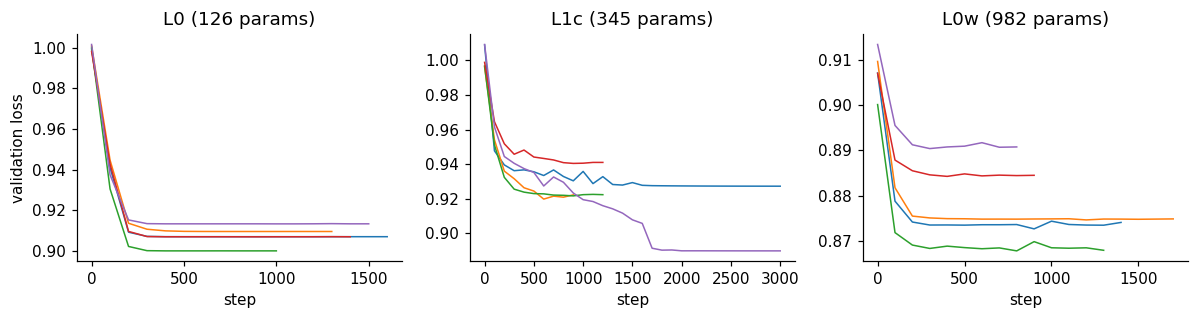

In [4]:
CK = os.path.join(RESULTS, "e1n_ck", MODE); os.makedirs(CK, exist_ok=True)
def split(f):
    test = folds[f]; train = np.zeros_like(test)
    for g in range(len(folds)):
        if g != f: train |= folds[g]
    return train, test
def inner(f):
    train = split(f)[0] & ds.mask()
    u = np.random.default_rng(100 + f).random(ds.mask().shape[1:]) < VAL_FRAC
    val = train & np.broadcast_to(u, train.shape)
    return train & ~val, val
def es_fit(name, f, L, init, seed, max_steps, patience):
    pth = os.path.join(CK, f"fold{f}_{name}.pkl")
    if os.path.exists(pth):
        d = pickle.load(open(pth, "rb")); return d["params"], d["es"]
    itr, val = inner(f); t0 = time.time()
    p, _ = lad.fit(L, ds, train_mask=itr, val_mask=val, init=None if init is None else to_jnp(init), steps=max_steps, lr=LR,
                   verbose=0, st=st, cfg=cfg, seed=seed, eval_every=EVAL_EVERY, patience=patience)
    es = dict(lad.LAST_EARLY_STOP, seconds=time.time() - t0); p = to_np(p)
    pickle.dump({"params": p, "es": es}, open(pth, "wb"))
    print(f"fold {f} {name:8s}: best step {es['best_step']:5d} / stopped {es['stopped_at']:5d} "
          f"({'patience' if es['by_patience'] else 'max steps'}) | validation loss {es['val_start']:.4f} -> {es['val_best']:.4f} "
          f"| {es['seconds']:.0f} s", flush=True)
    return p, es
FITS, INFO = [], {}
for f in range(len(folds)):
    FITS.append({})
    p0, INFO[(f, "L0")] = es_fit("L0", f, "L0", None, f, MAX_LIN, PAT_LIN); FITS[f]["L0"] = p0
    w0 = to_np(lad.extend_params(to_jnp(p0), "L0w", st, jax.random.PRNGKey(0)))
    FITS[f]["L0w"], INFO[(f, "L0w")] = es_fit("L0w", f, "L0w", w0, f, MAX_LIN, PAT_LIN)
    cands = [es_fit(f"L1c_r{r}", f, "L1c", None, f + 1000 * r, MAX_NL, PAT_NL) for r in range(RESTARTS_NL)]
    r_best = int(np.argmin([es["val_best"] for _, es in cands]))
    FITS[f]["L1c"], INFO[(f, "L1c")] = cands[r_best]; INFO[(f, "L1c")] = dict(INFO[(f, "L1c")], restart=r_best)
L0_CONVERGED_CLEAN = all(INFO[(f, "L0")]["best_step"] > 0 and INFO[(f, "L0")]["by_patience"]
                         and INFO[(f, "L0")]["stopped_at"] < MAX_LIN for f in range(len(folds)))
print("\nbest steps:", {L: [INFO[(f, L)]["best_step"] for f in range(len(folds))] for L in MODELS})
print("L1c restart kept per fold:", [INFO[(f, "L1c")]["restart"] for f in range(len(folds))])
print("Registered rule -> L0_CONVERGED_CLEAN:", L0_CONVERGED_CLEAN)

def W_eff(p, L):
    q = lad.tie(st, to_jnp(p)); W = q["a_exc"] * st.S_exc + q["a_inh"] * st.S_inh + q["a_unk"] * st.S_unk
    if L == "L0w":
        W = W + q["W"] * st.chem_mask * (st.S_exc + st.S_inh + st.S_unk)
    return np.asarray(W)
MOVE = [float(np.linalg.norm(W_eff(FITS[f]["L0w"], "L0w") - W_eff(FITS[f]["L0"], "L0")) / np.linalg.norm(W_eff(FITS[f]["L0"], "L0")))
        for f in range(len(folds))]
SIGN_FLIPS = [float(np.mean(np.sign(W_eff(FITS[f]["L0w"], "L0w"))[np.asarray(st.chem_mask) > 0]
                            != np.sign(W_eff(FITS[f]["L0"], "L0"))[np.asarray(st.chem_mask) > 0])) for f in range(len(folds))]
print("L0w: relative change of the effective weights vs its L0:", np.round(MOVE, 3), "| fraction of synapses with flipped sign:", np.round(SIGN_FLIPS, 3))
fig, ax = plt.subplots(1, len(MODELS), figsize=(11, 3))
for a, L in zip(ax, MODELS):
    for f in range(len(folds)):
        cv = np.array(INFO[(f, L)]["curve"]); a.plot(cv[:, 0], cv[:, 1], lw=1)
    a.set_title(f"{L} ({COUNT[L]} params)"); a.set_xlabel("step")
ax[0].set_ylabel("validation loss"); plt.tight_layout(); plt.show()

## 2 · Held-out comparison and E1's rules

model                     both      wt   unc31
L0                       0.300   0.292   0.317
L1c                      0.285   0.261   0.334
L0w                      0.376   0.350   0.431
L0 (NB25, all pairs)     0.421   0.374   0.520
L1 (NB25, all pairs)     0.303   0.269   0.377
  RESOLUTION_HELPS_LINEAR     L0w - L0 : +0.0759  95% CI [+0.0495, +0.1094]  -> True
  NONLINEARITY_HELPS_COMPACT  L1c - L0 : -0.0151  95% CI [-0.0495, +0.0151]  -> False
  clean L0 - NB25 round-2 L0: -0.1209  95% CI [-0.1764, -0.0760]

rung   gain over best shallower rung [95% CI]   needed?
L1c    -0.016 [-0.049, +0.015]               no
L0w    +0.075 [+0.049, +0.108]               yes
=> deepest needed rung L_needed = L0w
sufficiency L* = L0w | necessity L_needed = L0w | v4 = {'delta=0': 'L0w', 'delta[repeat]=0.000': 'L0w', 'delta[long]=0.003': 'L0w'}


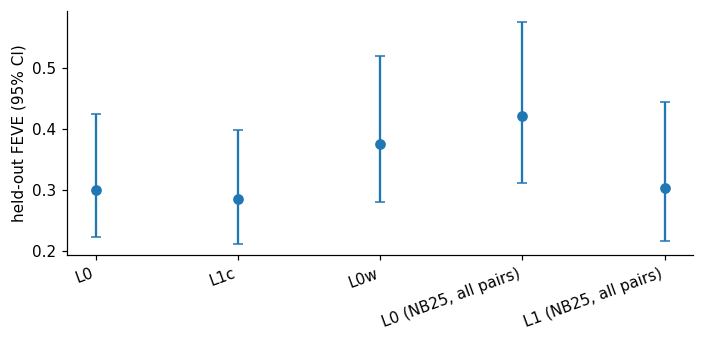

In [5]:
def full_pred(L, p):
    cols = np.arange(ds.S)
    return np.asarray(lad.predict(L, to_jnp(p), st, ds.stim, ds.strains, cfg, cols, proto=lad.proto_cols(ds, cols)))
def cv_from(L):
    out = np.zeros(ds.mean.shape)
    for f in range(len(folds)):
        msk = folds[f].reshape(folds[f].shape + (1,) * (ds.mean.ndim - 3))
        out = np.where(msk, full_pred(L, FITS[f][L]), out)
    return out
PRED = {L: cv_from(L) for L in MODELS}
if P25 is not None:
    PRED["L0 (NB25, all pairs)"] = P25["L0"]; PRED["L1 (NB25, all pairs)"] = P25["L1"]
names = list(PRED)
point, boots = M_.bootstrap_feve(PRED, ds, names, n_boot=N_BOOT, seed=0)
per = {s: M_.bootstrap_feve(PRED, ds, names, n_boot=200, seed=0, strain=s)[0] for s in ds.strains}
print(f"{'model':22s}{'both':>8s}" + "".join(f"{s:>8s}" for s in ds.strains))
for L in names:
    print(f"{L:22s}{point[L]:8.3f}" + "".join(f"{per[s][L]:8.3f}" for s in ds.strains))
CON = {}
for name, (x, y) in {"RESOLUTION_HELPS_LINEAR": ("L0w", "L0"), "NONLINEARITY_HELPS_COMPACT": ("L1c", "L0")}.items():
    d = boots[x] - boots[y]; lo, hi = np.percentile(d, [2.5, 97.5])
    CON[name] = dict(contrast=f"{x} - {y}", point=float(point[x] - point[y]), ci=[float(lo), float(hi)], holds=bool(lo > 0))
    print(f"  {name:27s} {x:3s} - {y:3s}: {point[x] - point[y]:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  -> {CON[name]['holds']}")
if P25 is not None:
    d = boots["L0"] - boots["L0 (NB25, all pairs)"]; lo, hi = np.percentile(d, [2.5, 97.5])
    print(f"  clean L0 - NB25 round-2 L0: {point['L0'] - point['L0 (NB25, all pairs)']:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]")
nec = M_.necessity(point, boots, ladder=LADDER)
suff = M_.closure_decision(point, boots, ladder=LADDER, threshold=THRESHOLD, blackbox=None)
v4 = {"delta=0": M_.calibrated_closure(boots, 0.0, LADDER)["L_closed"]}
v4.update({f"delta[{k}]={d:.3f}": M_.calibrated_closure(boots, d, LADDER)["L_closed"] for k, d in DELTA.items()})
print(); print(M_.format_necessity(nec))
print(f"sufficiency L* = {suff['L_star']} | necessity L_needed = {nec['L_needed']} | v4 = {v4}")
CLOSED_CLEAN = {"L_star": suff["L_star"], "L_needed": nec["L_needed"], "v4": v4}
fig, ax = plt.subplots(figsize=(6.5, 3.2))
mu = [point[L] for L in names]; lo = [np.percentile(boots[L], 2.5) for L in names]; hi = [np.percentile(boots[L], 97.5) for L in names]
ax.errorbar(range(len(names)), mu, yerr=[np.subtract(mu, lo), np.subtract(hi, mu)], fmt="o", capsize=3)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha="right"); ax.set_ylabel("held-out FEVE (95% CI)")
plt.tight_layout(); plt.show()

In [6]:
out = {"source": SOURCE, "early_stopping": ES, "free_parameters": COUNT, "ladder_by_parameters": list(LADDER),
       "L0_CONVERGED_CLEAN": L0_CONVERGED_CLEAN, "contrasts": CON, "CLOSED_CLEAN": CLOSED_CLEAN,
       "L0w_weight_change": MOVE, "L0w_sign_flips": SIGN_FLIPS,
       "heldout_feve": {L: float(point[L]) for L in names}, "per_strain": {s: {L: float(v) for L, v in per[s].items()} for s in per},
       "stopping": {f"{f}/{L}": {k: v for k, v in INFO[(f, L)].items() if k != "curve"} for f in range(len(folds)) for L in MODELS}}
json.dump(out, open(os.path.join(RESULTS, f"E1n_result{TAG}.json"), "w"), indent=2, default=float)
np.savez_compressed(os.path.join(RESULTS, f"E1n_heldout_predictions{TAG}.npz"), **{L: PRED[L] for L in MODELS})
print("saved", f"E1n_result{TAG}.json and E1n_heldout_predictions{TAG}.npz")

saved E1n_result_laptop.json and E1n_heldout_predictions_laptop.npz


## Results (laptop mode, run on the M1 Mac)

**Clean fits.** All fits left their starts this time.

| model | best step on the 5 folds | validation loss, start → best | time per fit |
|---|---|---|---|
| L0 (from scratch) | 1100, 800, 500, 900, 1000 | ≈ 1.00 → 0.900–0.913 | 1.5–2.3 min |
| `L0w` (from that L0) | 900, 1200, 800, 400, 300 | 0.900–0.913 → **0.868–0.890** | 3–6 min |
| `L1c` (best of 2 starts) | 3000, 600, 900, 900, 2900 | ≈ 1.00 → 0.890–0.941 | 1.5–5.7 min |

* `L0w`'s effective weights moved **12–16 %** away from its L0's, and **no synapse changed sign** on any fold.
* L0_CONVERGED_CLEAN = True by the registered rule: every L0 fit stopped by patience well before 6000 steps.

**Held-out FEVE (outer test pairs)**

| model | both strains | WT | unc-31 |
|---|---|---|---|
| L0, clean | 0.300 | 0.292 | 0.317 |
| `L1c`, clean | 0.285 | 0.261 | 0.334 |
| **`L0w`, clean** | **0.376** | 0.350 | 0.431 |
| L0, Notebook 25 (all training pairs, 2 refinement rounds) | **0.421** | 0.374 | 0.520 |
| L1, Notebook 25 | 0.303 | 0.269 | 0.377 |

* **RESOLUTION_HELPS_LINEAR = True:** `L0w` − L0 = **+0.076 [+0.050, +0.109]**.
* **NONLINEARITY_HELPS_COMPACT = False:** `L1c` − L0 = −0.015 [−0.050, +0.015].
* **CLOSED_CLEAN = `L0w`** under all three rules (sufficiency, necessity, v4 for every δ).
* Clean L0 − Notebook 25's L0 = **−0.121 [−0.176, −0.076]**.

**What this means: the registered outcome is "yes / no", but it is confounded.**
1. **The clean L0 is under-fitted, although the rule said it converged.** It reaches 0.300, essentially E1's original under-fitted L0 (0.295), and 0.12 below the L0 of Notebook 25.
   * Fitting on 80 % instead of 100 % of the training pairs can explain only a small part of that gap.
   * The rest is the optimizer: one Adam run at E1's learning rate plateaus on validation after about 1000 steps, and patience reads the plateau as convergence.
   * Notebooks 24–25 showed that the same model, given a *fresh* learning-rate schedule, keeps improving.
2. **`L0w`'s gain has the size of exactly that missing optimization.**
   * `L0w` started from the plateaued L0 and got another 300–1200 steps with a fresh schedule, for its synapse weights *and* L0's own parameters.
   * In Notebook 24, 300 such steps on plain L0 gave +0.080; `L0w`'s gain here is +0.076.
   * And `L0w` (0.376) is still below a well-optimized plain L0 (0.421).
   * So this notebook cannot say whether the synapse-specific weights or the extra optimization did the work. The same caveat applies to `L1c` ≈ L0: both are equally under-optimized.
3. **What the data do say.** If the synapse weights help, they do so modestly: a 12–16 % adjustment of contact-count weights, with not a single sign flip. The anatomy's sign and rough magnitude are kept.
4. **The lesson for the protocol.** Early stopping with a fixed patience is not a convergence test for these models. Notebook 28 (E1o) fits every model **to convergence by warm-restarted cycles** (`ladder.fit_cycles`, package 0.23): early-stopped runs, each restarted from the best point with a fresh schedule, until a cycle no longer improves validation. Only then does `L0w` add its synapse weights on top of a *converged* L0.


## 3 · Reading the result

| RESOLUTION_HELPS_LINEAR | NONLINEARITY_HELPS_COMPACT | reading for C2 |
|---|---|---|
| no | no | **E1's closed level is L0 in its strongest form.** Under single-neuron stimulation, the network is linear, and the effective weight of each synapse is set by the connectome's **contact count and sign** up to three class-wide factors. No synapse-specific tuning and no nonlinearity improves held-out prediction. The "software" is readable from the anatomy. |
| yes | no | **← observed, but confounded** with extra optimization of an under-fitted L0 (see Results; Notebook 28 resolves it). **Linear, but with weights of its own.** The closed level is `L0w`: the dynamics are linear, but the effective weights depart from contact counts in a way the data constrain. The program is not readable from anatomy alone; it must be measured. The size of the departure (§1) says by how much. |
| no | yes | **A compact nonlinear network is needed** once it is fitted cleanly. Notebook 26's negative result for `L1c` came from its start, and the closed level moves to `L1c`. |
| yes | yes | Both help. The closed level is the richer of the two by E1's rules (CLOSED_CLEAN); a combined model would be the next rung. |

L0_CONVERGED_CLEAN came out *yes*, but the clean L0 (0.300) is far below Notebook 25's (0.421): patience-based early stopping mistook a plateau for convergence. L0_CONVERGED_CLEAN = no means L0 was still improving at `MAX_LIN` on some fold, so its score is a lower bound. That would only strengthen a "no" for the two contrasts.

**Limits.**
* Clean fits use 80 % of the training pairs, so all three models are handicapped equally relative to Notebook 25's fits. The comparison to Notebook 25's L0 shows the cost of that handicap.
* `L0w` is fitted stage-wise from the clean L0; it can only depart from L0 where validation pairs support it.
* `laptop` mode is the 120 most-sampled neurons.